In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns; sns.set_style("white")
import pandas as pd
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import torch as pt

In [2]:
!ls /doctorai/marinafr/2023/airr_atlas/analysis/output/antiberta2/ireceptor/random

random_aa_idx.csv  random_idx.csv  random_shuffled_idx.csv  tsne
random_aa.pt	   random.pt	   random_shuffled.pt


In [8]:
# The sizes you want
sizes = [10000, 30000, 50000, 100000, 200000, 399900]

# The files you have
files = ["random_aa.pt", "random.pt", "random_shuffled.pt"]

base_path = "/doctorai/marinafr/2023/airr_atlas/analysis/output/antiberta2/ireceptor/random"

for fname in files:
    # Load tensor
    tensor = pt.load(f"{base_path}/{fname}")

    for size in sizes:
        if size > tensor.shape[0]:
            raise ValueError(f"Requested {size} rows, but {fname} has only {tensor.shape[0]} rows.")

        # Slice the first `size` rows
        subset = tensor[:size]

        # Save with size in filename
        save_name = fname.replace(".pt", f"_{size}.pt")
        pt.save(subset, f"{base_path}/tsne/{save_name}")

        print(f"Saved tsne/{save_name} with {size} rows")


Saved tsne/random_aa_10000.pt with 10000 rows
Saved tsne/random_aa_30000.pt with 30000 rows
Saved tsne/random_aa_50000.pt with 50000 rows
Saved tsne/random_aa_100000.pt with 100000 rows
Saved tsne/random_aa_200000.pt with 200000 rows
Saved tsne/random_aa_399900.pt with 399900 rows
Saved tsne/random_10000.pt with 10000 rows
Saved tsne/random_30000.pt with 30000 rows
Saved tsne/random_50000.pt with 50000 rows
Saved tsne/random_100000.pt with 100000 rows
Saved tsne/random_200000.pt with 200000 rows
Saved tsne/random_399900.pt with 399900 rows
Saved tsne/random_shuffled_10000.pt with 10000 rows
Saved tsne/random_shuffled_30000.pt with 30000 rows
Saved tsne/random_shuffled_50000.pt with 50000 rows
Saved tsne/random_shuffled_100000.pt with 100000 rows
Saved tsne/random_shuffled_200000.pt with 200000 rows
Saved tsne/random_shuffled_399900.pt with 399900 rows


Saved plot to /doctorai/marinafr/2023/airr_atlas/analysis/jupyter/tsne/ohe/random_shuffled/TSNE_random_shuffled_ohe_399900.pkl.png


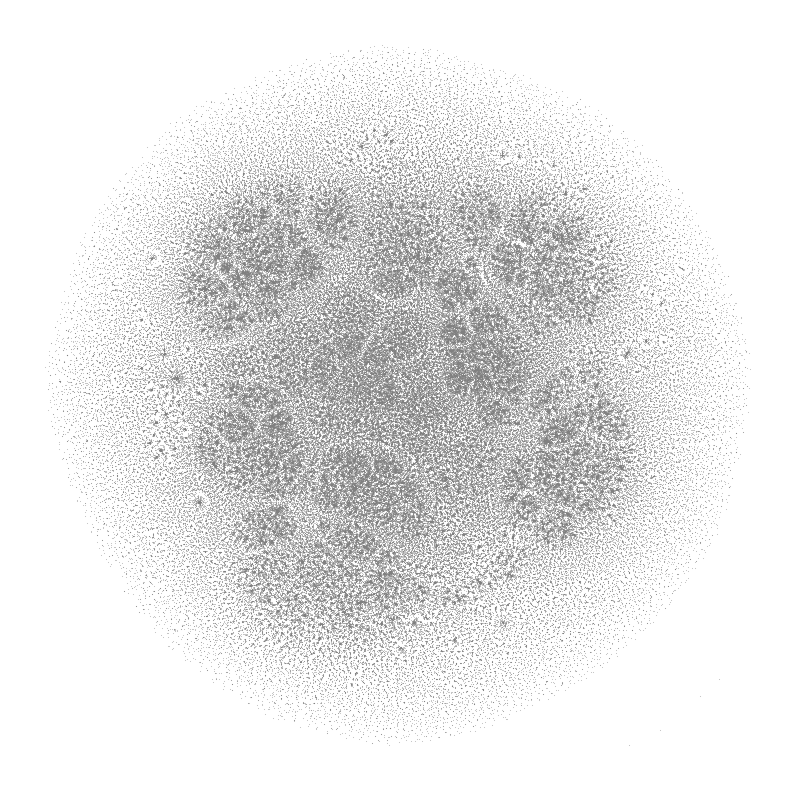

In [74]:
red = 'tsne'
model_name = 'ohe'
dataset_name = 'ireceptor/random' # dont change
dataset_name2 = 'random_shuffled'
dataset_size = '399900'


if model_name == 'antiberta2':
    short_model_name = 'ab2'
else:
    short_model_name = model_name


if int(dataset_size) >= 300_000:
    s_size = 0.6
    alpha_p = 0.5
elif 200_000 <= int(dataset_size) < 300_000:
    s_size = 0.8
    alpha_p = 0.5
elif 100_000 <= int(dataset_size) < 150_000:
    s_size = 0.8
    alpha_p = 0.7
elif 50_000 <= int(dataset_size) < 100_000:
    s_size = 0.8
    alpha_p = 0.9
elif 0 <= int(dataset_size) < 50_000:
    s_size = 0.9
    alpha_p = 1.0


df = pd.DataFrame(pd.read_pickle(f'/doctorai/marinafr/2023/airr_atlas/analysis/output/{model_name}/{dataset_name}/{red}/{red.upper()}_{dataset_name2}_{dataset_size}.pkl').values)
df.columns = ['x', 'y']

# Create the scatterplot
plt.figure(figsize=(10, 10))
scatter = sns.scatterplot(data=df, x='x', y='y', s=s_size, linewidth=0, alpha=alpha_p, color='grey'), #hue='dataset')

# Set axes' names
plt.xlabel(f'{red}_1', fontsize=20)
plt.ylabel(f'{red}_2', fontsize=20)

# Remove the spines
sns.despine(left=True, bottom=True)
plt.xticks([])
plt.yticks([])
plt.xlabel('')
plt.ylabel('')

#plt.xlim(-35, 35)
#plt.ylim(-35, 35)

#plt.xlim(-12, 12)
#plt.ylim(-12, 12)

# Save and show the plot
plt.savefig(f'/doctorai/marinafr/2023/airr_atlas/analysis/jupyter/tsne/{short_model_name}/{dataset_name2}/{red.upper()}_{dataset_name2}_{short_model_name}_{dataset_size}.pkl.png')
print(f"Saved plot to /doctorai/marinafr/2023/airr_atlas/analysis/jupyter/tsne/{short_model_name}/{dataset_name2}/{red.upper()}_{dataset_name2}_{short_model_name}_{dataset_size}.pkl.png")
plt.show()

# **Generate Gaussian data**

In [9]:
# Define parameters
num_points = 399990  # Number of points
dimensionality = 1280  # Dimensionality of the space
chunk_size = 5000  # Process in chunks to avoid memory issues
file_path = f"/doctorai/marinafr/2023/airr_atlas/analysis/jupyter/gaussian_1280d_{num_points}.npy"  # Output file

# Open a binary file for writing
with open(file_path, "wb") as f:
    data = np.random.randn(num_points, dimensionality).astype(np.float32)  # Use float32 to save memory
    np.save(f, data)

print(f"Dataset saved to {file_path}")

Dataset saved to /doctorai/marinafr/2023/airr_atlas/analysis/jupyter/gaussian_1280d_399990.npy


In [22]:
subset_size = 10000

subset = data[:subset_size]

file_path = f"/doctorai/marinafr/2023/airr_atlas/analysis/jupyter/gaussian_1280d_{subset_size}.npy"

with open(file_path, "wb") as f:
    np.save(f, subset)

print(f"Dataset saved to {file_path}")

Dataset saved to /doctorai/marinafr/2023/airr_atlas/analysis/jupyter/gaussian_1280d_10000.npy


In [25]:
dataset_size = '10000'

data = np.load(f'/doctorai/marinafr/2023/airr_atlas/analysis/jupyter/gaussian_1280d_{dataset_size}.npy')
len(data)

10000

In [55]:
from sklearn.manifold import TSNE
from umap import UMAP

dataset_size = '399990'

data = np.load(f'/doctorai/marinafr/2023/airr_atlas/analysis/jupyter/gaussian_1280d_{dataset_size}.npy')

#tsne_data = TSNE(random_state=42).fit_transform(data)
tsne_data = pd.DataFrame(UMAP(transform_seed=42, unique=True).fit_transform(data))

output_file = f'/doctorai/marinafr/2023/airr_atlas/analysis/jupyter/UMAP_gaussian_1280d_{dataset_size}.pkl'

# Create a DataFrame with t-SNE results
tsne_df = pd.DataFrame(tsne_data)

# Save the t-SNE result to a pickle file
tsne_df.to_pickle(output_file)
print(f"Saved {output_file}.pkl with {tsne_df.shape[0]} sequences")

tsne_df

Saved /doctorai/marinafr/2023/airr_atlas/analysis/jupyter/UMAP_gaussian_1280d_399990.pkl.pkl with 399990 sequences


,0,1
0,10.778503,3.588253
1,9.101489,5.006021
2,10.636812,3.853951
3,6.811610,4.997925
4,7.170009,5.473133
...,...,...
399985,11.129280,5.844859
399986,9.354811,4.861107
399987,9.614161,5.779815
399988,8.241021,6.026433


In [ ]:
tsne_df = pd.DataFrame(pd.read_pickle(f'/doctorai/marinafr/2023/airr_atlas/analysis/jupyter/normal_distribution_1280d.pkl').values)
tsne_df.columns = ['x', 'y']

tsne_df

,x,y
0,-0.851514,0.150890
1,-1.871451,-0.036402
2,1.186212,-1.879074
3,-1.827009,-1.989276
4,-3.174780,-0.831099
...,...,...
399985,1.202852,-0.688517
399986,2.027363,-0.936227
399987,-0.600593,-3.009740
399988,-2.607918,-0.657330


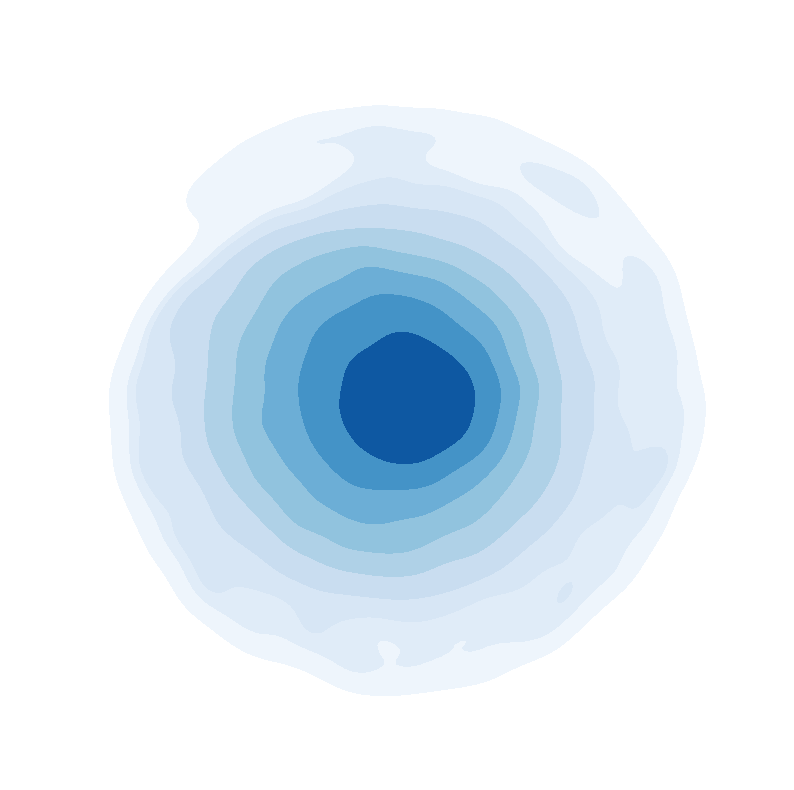

In [89]:
dataset_size = '200000'


if model_name == 'antiberta2':
    short_model_name = 'ab2'
else:
    short_model_name = model_name


if int(dataset_size) >= 300_000:
    s_size = 0.6
    alpha_p = 0.5
elif 200_000 <= int(dataset_size) < 300_000:
    s_size = 0.8
    alpha_p = 0.5
elif 100_000 <= int(dataset_size) < 150_000:
    s_size = 0.8
    alpha_p = 0.7
elif 50_000 <= int(dataset_size) < 100_000:
    s_size = 0.8
    alpha_p = 0.9
elif 0 <= int(dataset_size) < 50_000:
    s_size = 0.9
    alpha_p = 1.0


df = pd.DataFrame(pd.read_pickle(f'/doctorai/marinafr/2023/airr_atlas/analysis/jupyter/UMAP_gaussian_1280d_{dataset_size}.pkl').values)
df.columns = ['x', 'y']

# Create the scatterplot
plt.figure(figsize=(10, 10))
#scatter = sns.scatterplot(data=df, x='x', y='y', s=s_size, linewidth=0, alpha=alpha_p, color='grey'), #hue='dataset')
sns.kdeplot(data=df, x='x', y='y', fill=True, alpha=1, cmap="Blues")

# Set axes' names
plt.xlabel(f'{red}_1', fontsize=20)
plt.ylabel(f'{red}_2', fontsize=20)

# Remove the spines
sns.despine(left=True, bottom=True)
plt.xticks([])
plt.yticks([])
plt.xlabel('')
plt.ylabel('')

#plt.xlim(-5, 5)
#plt.ylim(-5, 5)

# Save and show the plot
plt.savefig(f'/doctorai/marinafr/2023/airr_atlas/analysis/jupyter/UMAP_KDE_gaussian_1280d_{dataset_size}.pkl.png')
plt.show()

Saved plot to /doctorai/marinafr/2023/airr_atlas/analysis/jupyter/tsne/ohe/random_shuffled/TSNE_hexbin_random_shuffled_ohe_399900.pkl.png


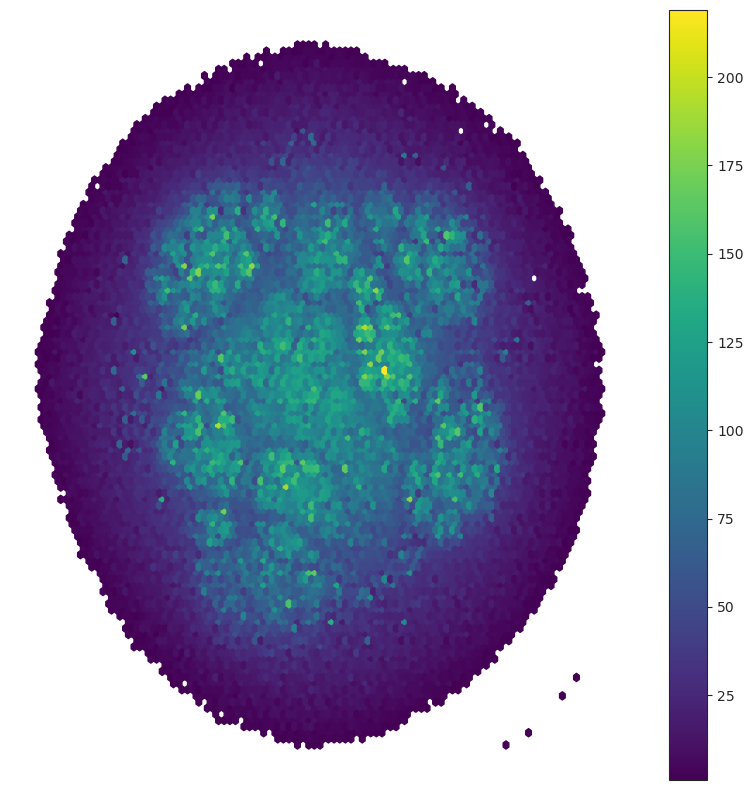

In [129]:
red = 'tsne'
model_name = 'ohe'
dataset_name = 'ireceptor/random' # dont change
dataset_name2 = 'random_shuffled'
dataset_size = '399900'


if model_name == 'antiberta2':
    short_model_name = 'ab2'
else:
    short_model_name = model_name


if int(dataset_size) >= 300_000:
    s_size = 0.6
    alpha_p = 0.5
    gridsize = 100
elif 200_000 <= int(dataset_size) < 300_000:
    s_size = 0.8
    alpha_p = 0.5
    gridsize = 100
elif 150_000 <= int(dataset_size) < 200_000:
    s_size = 0.8
    alpha_p = 0.5
    gridsize = 70
elif 100_000 <= int(dataset_size) < 150_000:
    s_size = 0.8
    alpha_p = 0.7
    gridsize = 70
elif 50_000 <= int(dataset_size) < 100_000:
    s_size = 0.8
    alpha_p = 0.9
    gridsize = 60
elif 0 <= int(dataset_size) < 50_000:
    s_size = 0.9
    alpha_p = 1.0
    gridsize = 50


df = pd.DataFrame(pd.read_pickle(f'/doctorai/marinafr/2023/airr_atlas/analysis/output/{model_name}/{dataset_name}/{red}/{red.upper()}_{dataset_name2}_{dataset_size}.pkl').values)
df.columns = ['x', 'y']

# Create the scatterplot
plt.figure(figsize=(10, 10))
#scatter = sns.scatterplot(data=df, x='x', y='y', s=s_size, linewidth=0, alpha=alpha_p, color='grey'), #hue='dataset')
hb = plt.hexbin(df.x, df.y, gridsize=gridsize, mincnt=1, cmap='viridis')
plt.colorbar(hb)  # Add colorbar

# Set axes' names
plt.xlabel(f'{red}_1', fontsize=20)
plt.ylabel(f'{red}_2', fontsize=20)

# Remove the spines
sns.despine(left=True, bottom=True)
plt.xticks([])
plt.yticks([])
plt.xlabel('')
plt.ylabel('')

#plt.xlim(-35, 35)
#plt.ylim(-35, 35)

#plt.xlim(-12, 12)
#plt.ylim(-12, 12)

# Save and show the plot
plt.savefig(f'/doctorai/marinafr/2023/airr_atlas/analysis/jupyter/tsne/{short_model_name}/{dataset_name2}/{red.upper()}_hexbin_{dataset_name2}_{short_model_name}_{dataset_size}.pkl.png')
print(f"Saved plot to /doctorai/marinafr/2023/airr_atlas/analysis/jupyter/tsne/{short_model_name}/{dataset_name2}/{red.upper()}_hexbin_{dataset_name2}_{short_model_name}_{dataset_size}.pkl.png")
plt.show()